Importing Deployment Data

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression

FS = 100
TRIM_S = 5

DEPLOYMENT_DIR = Path("../DeploymentData/DeploymentData")

print(DEPLOYMENT_DIR)

..\DeploymentData\DeploymentData


Load Calibrated Sensors

In [2]:
accelerometer = pd.read_csv(DEPLOYMENT_DIR / "Accelerometer.csv")
gravity = pd.read_csv(DEPLOYMENT_DIR / "Gravity.csv")
gyroscope = pd.read_csv(DEPLOYMENT_DIR / "Gyroscope.csv")

print("Accelerometer:", accelerometer.shape)
print("Gravity:", gravity.shape)
print("Gyroscope:", gyroscope.shape)

Accelerometer: (101926, 5)
Gravity: (101926, 5)
Gyroscope: (101926, 5)


Data check

In [3]:
print(accelerometer.head())
print()
print(gravity.head())
print()
print(gyroscope.head())

                  time  seconds_elapsed         z         y         x
0  1724854953146595800         0.053596  1.773704 -1.076428 -1.711618
1  1724854953156648000         0.063648  1.043526 -0.820191 -1.178875
2  1724854953166699800         0.073700  0.543858  0.433552 -0.208286
3  1724854953176751900         0.083752  0.340438  0.328924 -0.475290
4  1724854953186803700         0.093804  0.309068 -0.190948 -0.789170

                  time  seconds_elapsed         z         y         x
0  1724854953146595800         0.053596 -8.725118 -4.015740  1.979021
1  1724854953156648000         0.063648 -8.684771 -4.003677  2.171570
2  1724854953166699800         0.073700 -8.640898 -3.984003  2.373392
3  1724854953176751900         0.083752 -8.595646 -3.960479  2.569020
4  1724854953186803700         0.093804 -8.549760 -3.935159  2.754361

                  time  seconds_elapsed         z         y         x
0  1724854953146595800         0.053596 -1.706805  1.315095  0.294301
1  172485495315664

In [4]:
print(accelerometer.columns.tolist())
print(gravity.columns.tolist())
print(gyroscope.columns.tolist())

['time', 'seconds_elapsed', 'z', 'y', 'x']
['time', 'seconds_elapsed', 'z', 'y', 'x']
['time', 'seconds_elapsed', 'z', 'y', 'x']


Alignment

In [7]:
TOL_S = 0.005

acc = accelerometer[["seconds_elapsed", "x", "y", "z"]].copy()
gyro = gyroscope[["seconds_elapsed", "x", "y", "z"]].copy()
grav = gravity[["seconds_elapsed", "x", "y", "z"]].copy()

acc.columns = ["t", "acc_x", "acc_y", "acc_z"]
gyro.columns = ["t", "gyro_x", "gyro_y", "gyro_z"]
grav.columns = ["t", "grav_x", "grav_y", "grav_z"]

acc = acc.sort_values("t")
gyro = gyro.sort_values("t")
grav = grav.sort_values("t")

aligned = pd.merge_asof(acc,gyro,on="t",direction="nearest",tolerance=TOL_S,)

aligned = pd.merge_asof(aligned, grav,on="t",direction="nearest",tolerance=TOL_S,)
   

aligned = aligned.dropna().reset_index(drop=True)

for axis in "xyz":
    aligned[f"tacc_{axis}"] = (aligned[f"acc_{axis}"] + aligned[f"grav_{axis}"])

print(aligned.shape)
print(aligned.head())

(101926, 13)
          t     acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z  \
0  0.053596 -1.711618 -1.076428  1.773704  0.294301  1.315095 -1.706805   
1  0.063648 -1.178875 -0.820191  1.043526  0.233846  1.511946 -1.691947   
2  0.073700 -0.208286  0.433552  0.543858  0.181056  1.584875 -1.587968   
3  0.083752 -0.475290  0.328924  0.340438  0.150255  1.529373 -1.451684   
4  0.093804 -0.789170 -0.190948  0.309068  0.109078  1.511204 -1.296045   

     grav_x    grav_y    grav_z    tacc_x    tacc_y    tacc_z  
0  1.979021 -4.015740 -8.725118  0.267403 -5.092168 -6.951415  
1  2.171570 -4.003677 -8.684771  0.992696 -4.823867 -7.641244  
2  2.373392 -3.984003 -8.640898  2.165106 -3.550451 -8.097040  
3  2.569020 -3.960479 -8.595646  2.093729 -3.631555 -8.255207  
4  2.754361 -3.935159 -8.549760  1.965191 -4.126108 -8.240692  


Trimming

In [9]:
def trim(df: pd.DataFrame, trim_s: float = TRIM_S) -> pd.DataFrame:
    t0 = df["t"].iloc[0] + trim_s
    t1 = df["t"].iloc[-1] - trim_s

    return df[
        (df["t"] >= t0) &
        (df["t"] <= t1)
    ].reset_index(drop=True)


trimmed = trim(aligned)

print("Original samples:", len(aligned))
print("Trimmed samples:", len(trimmed))
print("Original duration:", aligned["t"].iloc[-1] - aligned["t"].iloc[0], "s")
print("Trimmed duration:", trimmed["t"].iloc[-1] - trimmed["t"].iloc[0], "s")

Original samples: 101926
Trimmed samples: 100930
Original duration: 1024.5269211425784 s
Trimmed duration: 1014.5153195800782 s


Feature engineering / derived channels

In [10]:
def add_channels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Gravity unit vector
    g = df[["grav_x", "grav_y", "grav_z"]].to_numpy()
    g = g / np.linalg.norm(g, axis=1, keepdims=True)

    # Accelerometer
    a = df[["acc_x", "acc_y", "acc_z"]].to_numpy()

    # Acceleration magnitude
    df["acc_mag"] = np.linalg.norm(a, axis=1)

    # Vertical acceleration
    df["acc_vertical"] = (a * g).sum(axis=1)

    # Horizontal acceleration
    df["acc_horizontal"] = np.sqrt(np.clip(df["acc_mag"] ** 2 - df["acc_vertical"] ** 2,0,None,))

    # Gyroscope magnitude
    df["gyro_mag"] = np.linalg.norm(
        df[["gyro_x", "gyro_y", "gyro_z"]].to_numpy(),
        axis=1,)

    # Total acceleration magnitude
    df["tacc_mag"] = np.linalg.norm(
        df[["tacc_x", "tacc_y", "tacc_z"]].to_numpy(),
        axis=1,)

    return df


trimmed = add_channels(trimmed)

print(trimmed.columns.tolist())

['t', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'tacc_x', 'tacc_y', 'tacc_z', 'acc_mag', 'acc_vertical', 'acc_horizontal', 'gyro_mag', 'tacc_mag']


Band-pass filter

In [11]:
BAND = (3.0, 20.0)

def bandpass(
    x: np.ndarray,
    lo: float = BAND[0],
    hi: float = BAND[1],
    fs: int = FS,
) -> np.ndarray:
    """Zero-phase FFT band-pass: keep only bins with lo <= f <= hi."""
    X = np.fft.rfft(x - x.mean())
    f = np.fft.rfftfreq(len(x), 1 / fs)
    X[(f < lo) | (f > hi)] = 0
    return np.fft.irfft(X, len(x))


trimmed["acc_vertical_filtered"] = bandpass(
    trimmed["acc_vertical"].to_numpy()
)

print(trimmed.columns.tolist())

['t', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'tacc_x', 'tacc_y', 'tacc_z', 'acc_mag', 'acc_vertical', 'acc_horizontal', 'gyro_mag', 'tacc_mag', 'acc_vertical_filtered']


Create Windows

In [12]:
WIN_S, STEP_S = 4, 2
WIN, STEP = WIN_S * FS, STEP_S * FS

CHANNELS = [
    "acc_vertical",
    "acc_vertical_filtered",
    "acc_horizontal",
    "gyro_mag",
    "tacc_mag",
]

def make_windows(
    df: pd.DataFrame,
    win: int = WIN,
    step: int = STEP,
    channels=CHANNELS,
):
    arr = df[channels].to_numpy(np.float32)
    starts = range(0, len(df) - win + 1, step)

    X = (
        np.stack([arr[s:s + win] for s in starts])
        if len(df) >= win
        else np.empty((0, win, len(channels)), np.float32)
    )

    meta = [
        {
            "window_id": f"deployment_W{i:03d}",
            "t_start": df["t"].iloc[s],
        }
        for i, s in enumerate(starts)
    ]

    return X, meta


X_external, windows_meta = make_windows(trimmed)

print(f"X_external: {X_external.shape}")
print(f"Number of windows: {len(windows_meta)}")

X_external: (503, 400, 5)
Number of windows: 503


Feature Extraction

In [ ]:
BANDS = [(0.5, 3),(3, 8),(8, 15),(15, 30),(30, 50),]


def time_feats(x, name):
    x = x - x.mean()
    s = x.std() + 1e-12

    return {
        f"{name}_std": x.std(),
        f"{name}_iqr": np.subtract(*np.percentile(x, [75, 25])),
        f"{name}_p2p": np.ptp(x),
        f"{name}_p95abs": np.percentile(np.abs(x), 95),
        f"{name}_madiff": np.abs(np.diff(x)).mean(),
        f"{name}_kurt": ((x / s) ** 4).mean(),
        f"{name}_skew": ((x / s) ** 3).mean(),
        f"{name}_zcr": (np.diff(np.sign(x)) != 0).mean(),}


def spec_feats(x, name):
    w = np.hanning(len(x))
    P = np.abs(np.fft.rfft((x - x.mean()) * w)) ** 2
    f = np.fft.rfftfreq(len(x), 1 / FS)

    tot = P[f >= 0.5].sum() + 1e-12
    out = {}

    for lo, hi in BANDS:
        out[f"{name}_bp{lo}-{hi}"] = P[(f >= lo) & (f < hi)].sum()

        out[f"{name}_bf{lo}-{hi}"] = (out[f"{name}_bp{lo}-{hi}"] / tot)

    p = P[f >= 0.5] / tot

    out[f"{name}_centroid"] = (f[f >= 0.5] * p).sum()

    out[f"{name}_domfreq"] = (f[f >= 0.5][p.argmax()])

    out[f"{name}_spec_entropy"] = -(p[p > 0] * np.log(p[p > 0])).sum()

    return out


def extract_features_deployment(window):
    ch = {c: window[:, i] for i, c in enumerate(CHANNELS)}

    return (
        time_feats(ch["acc_vertical"], "vert")
        | time_feats(ch["acc_vertical_filtered"], "vertbp")
        | time_feats(ch["acc_horizontal"], "horiz")
        | time_feats(ch["gyro_mag"], "gyro")
        | time_feats(ch["tacc_mag"], "tacc")
        | spec_feats(ch["acc_vertical"], "vert")
        | spec_feats(ch["gyro_mag"], "gyro"))


external_feature_list = [extract_features_deployment(window) for window in X_external]

features_external = pd.DataFrame(external_feature_list)

print("External feature matrix shape:", features_external.shape)
print(features_external.head())
    


External feature matrix shape: (503, 66)
   vert_std  vert_iqr   vert_p2p  vert_p95abs  vert_madiff  vert_kurt  \
0  1.024854  0.967541   7.861570     2.342662     0.392501   5.276102   
1  1.495225  1.292286  12.004137     2.875077     0.430565   8.661670   
2  1.426398  1.250995  12.004137     2.917451     0.371579   9.966023   
3  0.960141  1.152863   6.407960     1.846441     0.318218   4.148108   
4  1.051499  1.430101   6.775074     1.979785     0.370999   3.445024   

   vert_skew  vert_zcr  vertbp_std  vertbp_iqr  ...  gyro_bf3-8  gyro_bp8-15  \
0   0.322880  0.175439    0.953073    0.879567  ...    0.073457    83.860671   
1   1.223483  0.137845    1.218079    1.220885  ...    0.110238    57.826591   
2   1.345170  0.152882    1.064940    0.925074  ...    0.034679    37.912324   
3  -0.549436  0.147870    0.636558    0.718317  ...    0.023163    57.400236   
4  -0.286148  0.132832    0.756751    0.960339  ...    0.045069    73.378905   

   gyro_bf8-15  gyro_bp15-30  gyro_bf15

Set final k and pipeline

In [ ]:
def mi_score(X, y):
    return mutual_info_classif(X, y, random_state=42)

K = 24

final_pipeline = Pipeline([("scaler", StandardScaler()),("features", SelectKBest(score_func=mi_score,k=K,)),
    ("model", LogisticRegression(max_iter=5000,random_state=42,)),])

print(final_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('features',
                 SelectKBest(k=24,
                             score_func=<function mutual_info_classif at 0x000002611B4C67A0>)),
                ('model', LogisticRegression(max_iter=5000, random_state=42))])


Load Training Features

In [19]:
TRAINING_FEATURES_PATH = Path("../results/features.csv")

training_features = pd.read_csv(TRAINING_FEATURES_PATH)

print("Training shape:", training_features.shape)
print(training_features.head())
print(training_features.columns.tolist())

Training shape: (324, 72)
      window_id recording_id participant  label    t_start  fold  vert_std  \
0  P01_B01_W000      P01_B01         P01  bumpy   5.166381     3  2.380148   
1  P01_B01_W001      P01_B01         P01  bumpy   9.166381     3  2.271596   
2  P01_B01_W002      P01_B01         P01  bumpy  13.166381     3  2.021526   
3  P01_B01_W003      P01_B01         P01  bumpy  17.166381     3  1.974017   
4  P01_B01_W004      P01_B01         P01  bumpy  21.166381     3  2.152333   

   vert_iqr   vert_p2p  vert_p95abs  ...  gyro_bf3-8  gyro_bp8-15  \
0  3.079933  16.912586     4.821896  ...    0.137235  6679.122300   
1  2.993544  16.912586     4.530028  ...    0.065298  5267.073384   
2  2.773302  14.236208     3.885352  ...    0.040794  4476.411694   
3  2.577704  13.393045     3.824007  ...    0.048458  4171.967825   
4  2.838318  15.481230     4.145452  ...    0.042682  3686.849263   

   gyro_bf8-15  gyro_bp15-30  gyro_bf15-30  gyro_bp30-50  gyro_bf30-50  \
0     0.048090  

Prepare Training Data and Top-24 MI Features

In [ ]:
# Separate metadata from numerical features
metadata_columns = ["window_id","recording_id","participant","label","t_start","fold",]

X_train_full = training_features.drop(columns=metadata_columns)

y_train_full = training_features["label"]

# Load feature scores from the training process
FEATURE_SCORES_PATH = Path("../results/feature_scores.csv")

feature_scores = pd.read_csv(FEATURE_SCORES_PATH)

# Select the 24 features with the highest Mutual Information
top_24_features = (feature_scores.sort_values("MI_bits", ascending=False).head(24)["feature"].tolist())

X_train_selected = X_train_full[top_24_features]

print("Training feature matrix:", X_train_selected.shape)
print("\nTop-24 MI features:")
print(top_24_features)
print("\nLabels:")
print(y_train_full.value_counts())

Training feature matrix: (324, 24)

Top-24 MI features:
['vertbp_madiff', 'vertbp_iqr', 'vert_bp8-15', 'vert_bp15-30', 'horiz_madiff', 'vert_bp3-8', 'vert_bp30-50', 'vertbp_p2p', 'horiz_p2p', 'vert_p95abs', 'gyro_bp15-30', 'horiz_iqr', 'gyro_bf15-30', 'gyro_bp8-15', 'vert_centroid', 'vert_bf0.5-3', 'vert_iqr', 'vert_skew', 'vert_zcr', 'vert_spec_entropy', 'gyro_bp30-50', 'vert_bf3-8', 'gyro_madiff', 'gyro_bf8-15']

Labels:
label
bumpy     166
smooth    158
Name: count, dtype: int64


Train Final Logistic Regression

In [ ]:
# Train the final Logistic Regression model on the full training dataset

final_pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=5000,random_state=42,)),])

final_pipeline.fit(X_train_selected,y_train_full,)

print("Final Logistic Regression trained successfully.")

Final Logistic Regression trained successfully.


Predict External Dataset

In [22]:
# Predict road-surface quality for the external dataset

X_external_selected = features_external[top_24_features]

external_predictions = final_pipeline.predict(
    X_external_selected
)

print("External predictions:", len(external_predictions))
print("\nPrediction counts:")
print(pd.Series(external_predictions).value_counts())

External predictions: 503

Prediction counts:
smooth    466
bumpy      37
Name: count, dtype: int64


Create Deployment Results

In [23]:
# Create a results table linking each prediction to its road section

deployment_results = pd.DataFrame({
    "window_id": [meta["window_id"] for meta in windows_meta],
    "t_start": [meta["t_start"] for meta in windows_meta],
    "prediction": external_predictions,
})

deployment_results["t_end"] = (
    deployment_results["t_start"] + WIN_S
)

deployment_results = deployment_results[
    ["window_id", "t_start", "t_end", "prediction"]
]

print("Deployment results:", deployment_results.shape)
print(deployment_results.head(10))

Deployment results: (503, 4)
         window_id    t_start      t_end prediction
0  deployment_W000   5.059440   9.059440     smooth
1  deployment_W001   7.069816  11.069816     smooth
2  deployment_W002   9.080189  13.080189     smooth
3  deployment_W003  11.090556  15.090556     smooth
4  deployment_W004  13.100914  17.100914     smooth
5  deployment_W005  15.111264  19.111264     smooth
6  deployment_W006  17.121605  21.121605     smooth
7  deployment_W007  19.131940  23.131940     smooth
8  deployment_W008  21.142269  25.142269     smooth
9  deployment_W009  23.152594  27.152594     smooth


Visualize Smooth and Bumpy Sections

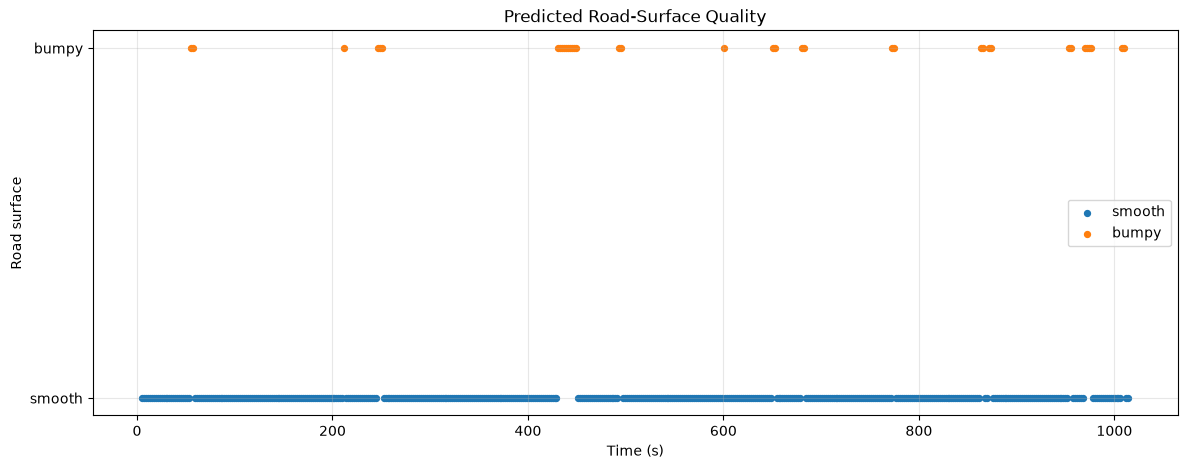

In [24]:
# Visualize predicted road-surface quality along the route

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

for label in ["smooth", "bumpy"]:
    mask = deployment_results["prediction"] == label

    plt.scatter(
        deployment_results.loc[mask, "t_start"],
        deployment_results.loc[mask, "prediction"],
        label=label,
        s=18,
    )

plt.xlabel("Time (s)")
plt.ylabel("Road surface")
plt.title("Predicted Road-Surface Quality")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Continuous Road-Section Visualization

In [ ]:
# Visualize continuous smooth and bumpy road sections

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))

for _, row in deployment_results.iterrows():
    if row["prediction"] == "bumpy":
        plt.axvspan(
            row["t_start"],
            row["t_end"],
            alpha=0.5,
        )

plt.axhline(0, linewidth=2)

plt.yticks([])
plt.xlabel("Time along route (s)")
plt.title("Predicted Bike-Lane Quality Along the Route")
plt.xlim(
    deployment_results["t_start"].min(),
    deployment_results["t_end"].max(),
)

plt.grid(axis="x", alpha=0.3)
plt.show()